In [1]:
from experiment_common_code import ExperimentResult, plot_metrics_by_group, plot_confusion_matrix
from common_constants import LANGUAGES, MODEL_NAMES
from icecream import ic

import torch as t
from itertools import permutations

from typing import Literal

device: Literal["cuda", "cpu"] = "cuda" if t.cuda.is_available() else "cpu"

# Experiment 1

In [2]:
from experiment_1 import run_experiment_1

model_names: list[str] = MODEL_NAMES
languages: list[str] = LANGUAGES
probe_type: str = "lr"
num_layers: int | None = None

custom = True
if custom:
    model_names = ["olmo_model"]
    languages = ["en"]
    probe_type = "lr"
    print(f"Using custom configuration")

limited_layers = True
if limited_layers:
    num_layers = 3

force_probe_creation: bool = True

ic(custom, limited_layers, force_probe_creation)

ic(model_names, languages, probe_type)

ic| custom: True, limited_layers: True, force_probe_creation: True
ic| model_names: ['olmo_model'], languages: ['en'], probe_type: 'lr'


Using custom configuration


(['olmo_model'], ['en'], 'lr')

In [3]:
save_results: bool = True

run_experiment_1(languages, "standard", "control", probe_type, model_names, force_probe_creation, num_layers=num_layers, save_results=save_results)

Running experiment 1 instance. en, control, lr, olmo_model
Probing at layer 0
Creating probe
Probe saved to probes\olmo_model\lr_en_layer0_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([1, 1, 1,  ..., 1, 2, 1])
Probing at layer 1
Creating probe
Probe saved to probes\olmo_model\lr_en_layer1_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([1, 1, 1,  ..., 1, 0, 1])
Probing at layer 2
Creating probe
Probe saved to probes\olmo_model\lr_en_layer2_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([1, 1, 1,  ..., 1, 1, 1])
Running experiment 1 instance. en, standard, lr, olmo_model
Probing at layer 0
Creating probe
Probe saved to probes\olmo_model\lr_en_layer0_standa

In [5]:
exp_result: ExperimentResult = ExperimentResult.get_from_file(
                    1, "en", "standard", probe_type, "olmo_model"
                )

exp_result.metrics["test"]

{'cm': [array([[ 524,  538,  342],
         [ 933, 1164,  693],
         [ 284,  250,  178]], dtype=int64),
  array([[ 544,  513,  347],
         [1019, 1064,  707],
         [ 260,  251,  201]], dtype=int64),
  array([[ 510,  540,  354],
         [ 994, 1081,  715],
         [ 254,  271,  187]], dtype=int64)],
 'accuracy': [0.38035059111292296, 0.3687321646962903, 0.36241337138198126],
 'per_class_precision': [[0.3009764503159104,
   0.5963114754098361,
   0.14674361088211046],
  [0.2984092155787164, 0.5820568927789934, 0.1601593625498008],
  [0.2901023890784983, 0.571353065539112, 0.14888535031847133]],
 'per_class_recall': [[0.3732193732193732, 0.4172043010752688, 0.25],
  [0.38746438746438744, 0.3813620071684588, 0.28230337078651685],
  [0.36324786324786323, 0.3874551971326165, 0.26264044943820225]],
 'per_class_f1': [[0.33322734499205087,
   0.490932096161957,
   0.18493506493506492],
  [0.33715525255655404, 0.46080554352533565, 0.2043721403152008],
  [0.3225806451612903, 0.461768

Common attributes={'language': 'en', 'probe_type': 'lr', 'model_name': 'olmo_model', 'split': 'test', 'metric': 'precision'}
Varying attributes={'probing_task'}
Common attributes={'language': 'en', 'probe_type': 'lr', 'model_name': 'olmo_model', 'split': 'train', 'metric': 'precision'}
Varying attributes={'probing_task'}


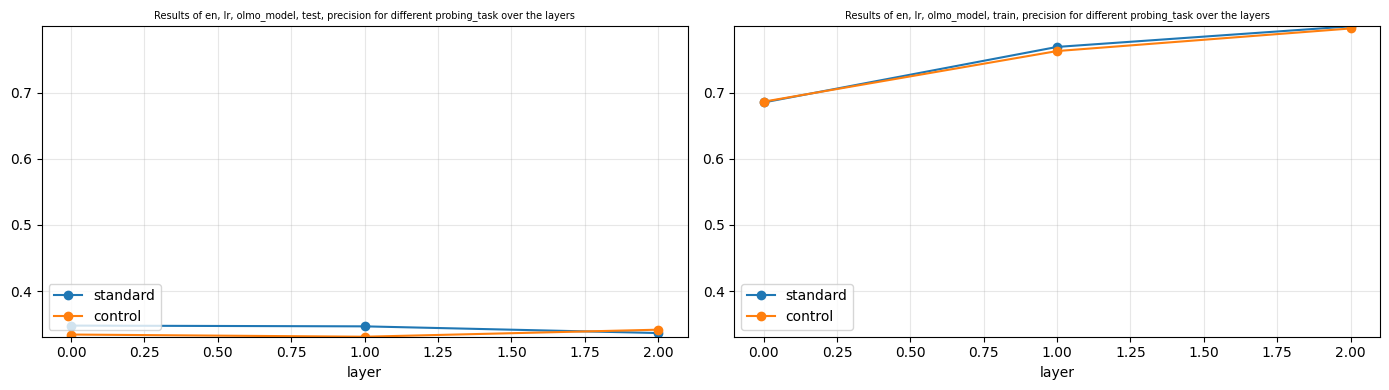

In [6]:
plots_to_make: list[list[tuple[ExperimentResult, str, str]]] = []
for model_name in model_names:
    for split in ["test", "train"]:
        # Get all the experiments for this model across all languages and probing_tasks
        experiments_in_plot: list[tuple[ExperimentResult, str, str]] = []
        for language in languages:
            for probing_task in ["standard", "control"]:
                exp_result: ExperimentResult = ExperimentResult.get_from_file(
                    1, language, probing_task, probe_type, model_name
                )
                experiments_in_plot.append((exp_result, split, "precision"))
                # experiments_in_plot.append((exp_result, split, "baseline_constant_accuracy"))
                # print(exp_result.metrics[split])

        plots_to_make.append(experiments_in_plot)
# Make some plots
plot_metrics_by_group(plots_to_make, "layer", show=True)

{'cm': [array([[ 524,  539,  341],
       [ 934, 1162,  694],
       [ 282,  251,  179]], dtype=int64)], 'accuracy': [0.38014675907052586], 'per_class_precision': [[0.30114942528735633, 0.5952868852459017, 0.14744645799011533]], 'per_class_recall': [[0.3732193732193732, 0.4164874551971326, 0.25140449438202245]], 'per_class_f1': [[0.33333333333333337, 0.49008857022353447, 0.18587746625129803]], 'precision': [0.34796092284112445], 'recall': [0.3470371075995094], 'f1': [0.3364331232693886], 'marginal_accuracy': [0.008560945780676676], 'marginal_per_class_precision': [[0.016297282861285123, 0.023788830771193537, -8.078425632221387e-05]], 'marginal_per_class_recall': [[0.03143805533378308, -3.150970892906724e-05, 0.0014044943820224476]], 'marginal_per_class_f1': [[0.02260258942286597, 0.008234971699851878, 0.0003213249755995573]], 'marginal_precision': [0.013335109792052149], 'marginal_recall': [0.010937013335625486], 'marginal_f1': [0.010386295366105802]}
{'cm': [array([[ 462,  589,  353],

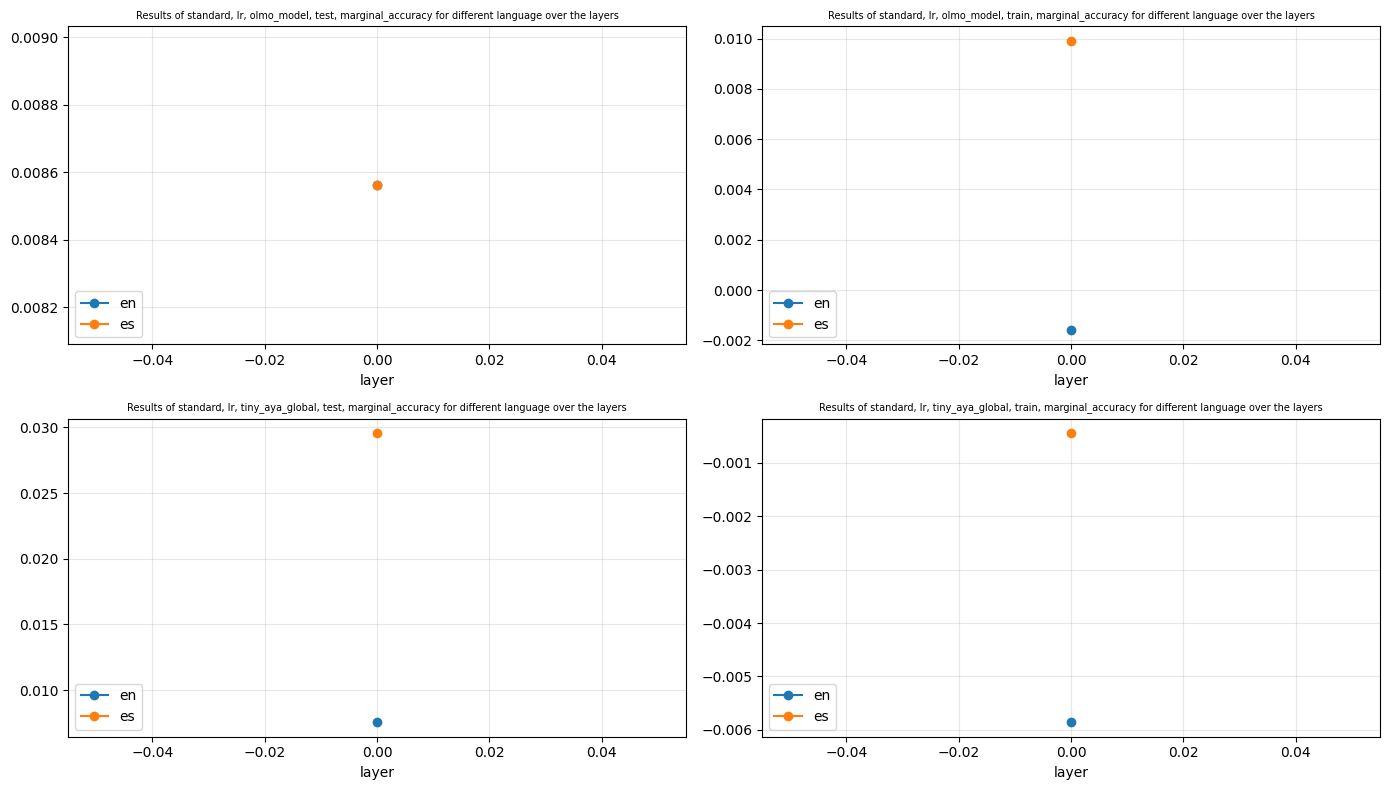

In [7]:
plots_to_make: list[list[tuple[ExperimentResult, str, str]]] = []
for model_name in model_names:
    for split in ["test", "train"]:
        # Get all the experiments for this model across all languages and probing_tasks
        experiments_in_plot: list[tuple[ExperimentResult, str, str]] = []
        for language in languages:
            exp_result: ExperimentResult = ExperimentResult.get_from_file(
                1, language, "standard", probe_type, model_name
            )
            experiments_in_plot.append((exp_result, split, "marginal_accuracy"))
            # experiments_in_plot.append((exp_result, split, "baseline_constant_accuracy"))
            print(exp_result.metrics[split])

        plots_to_make.append(experiments_in_plot)
# Make some plots
plot_metrics_by_group(plots_to_make, "layer", show=True)

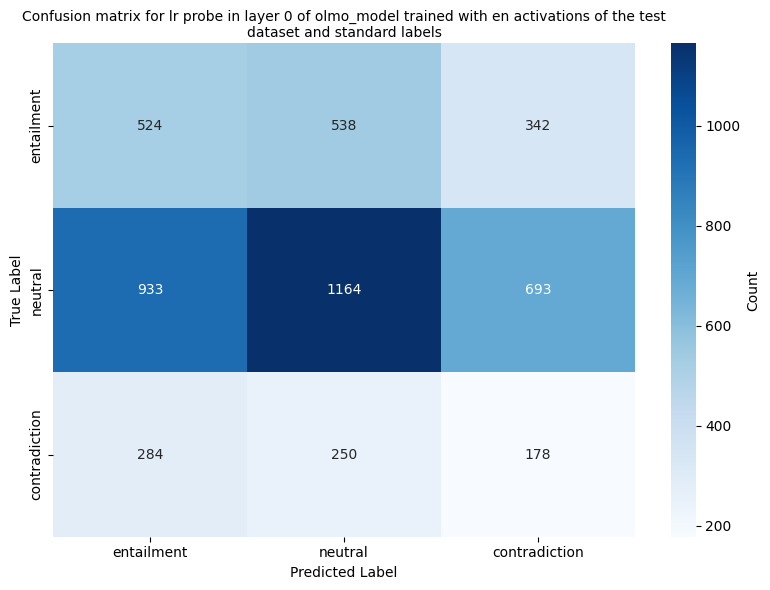

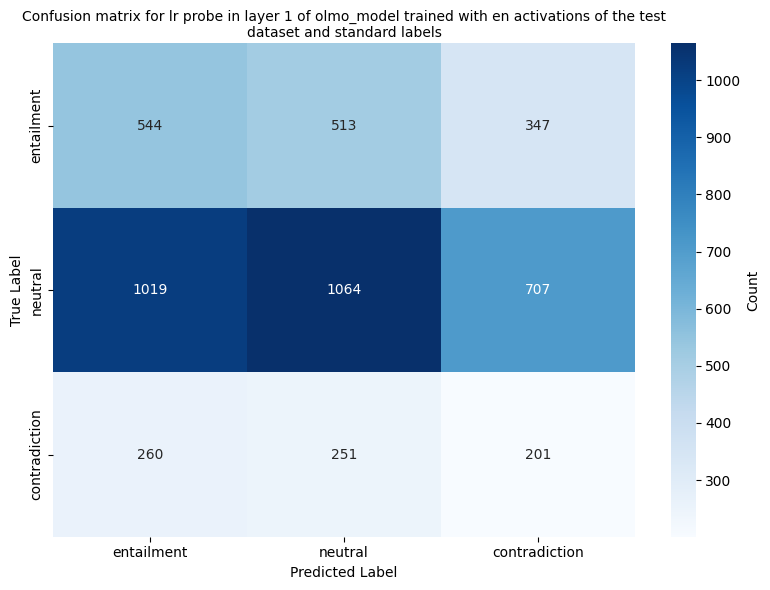

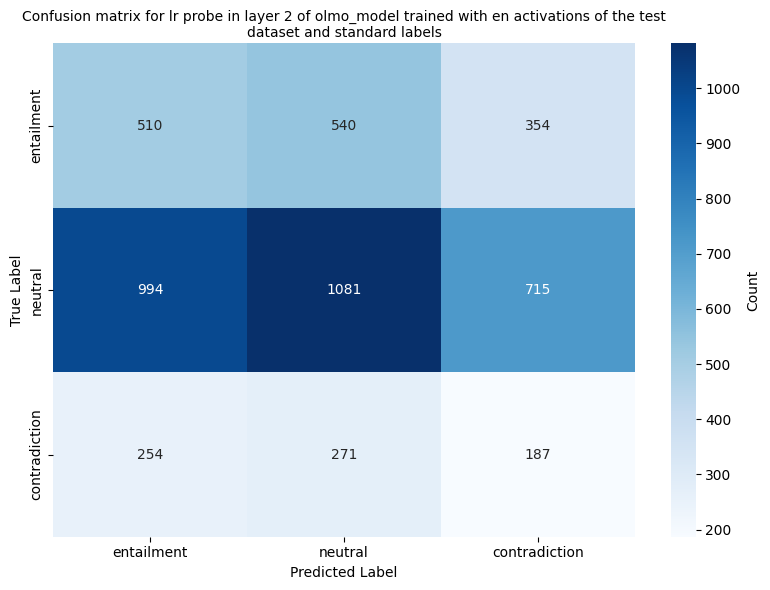

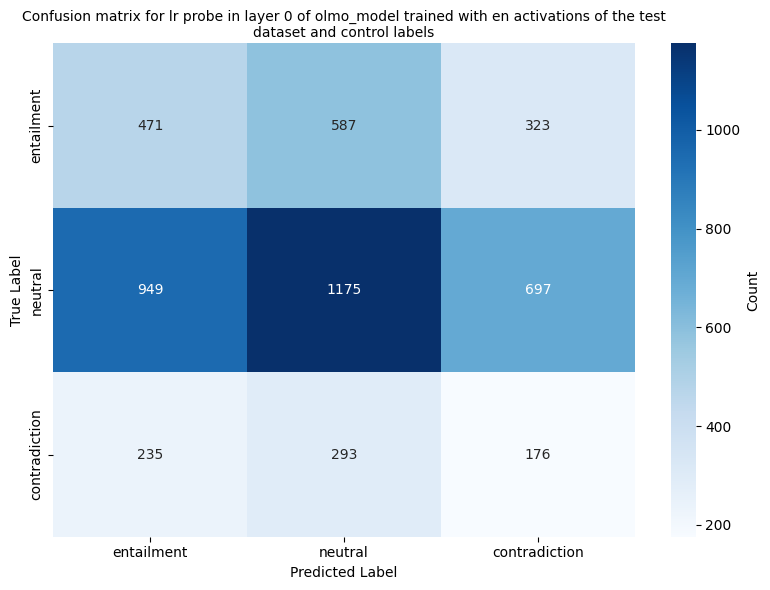

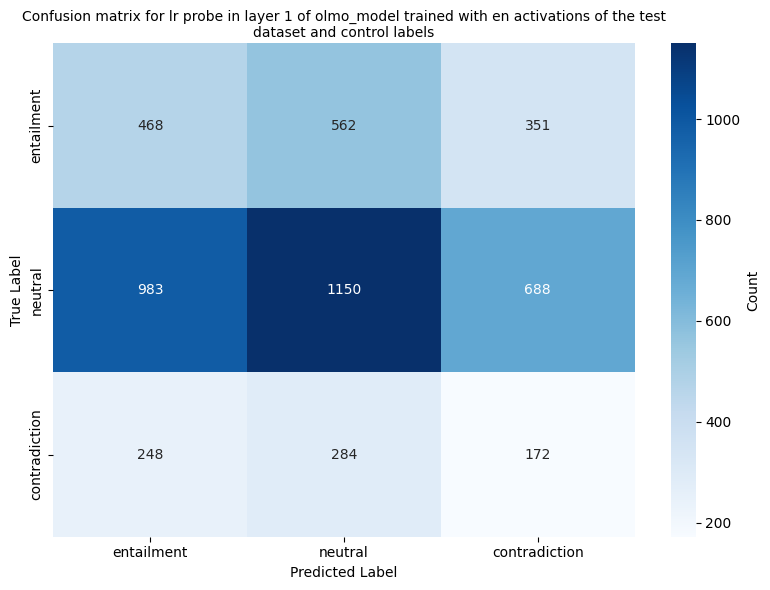

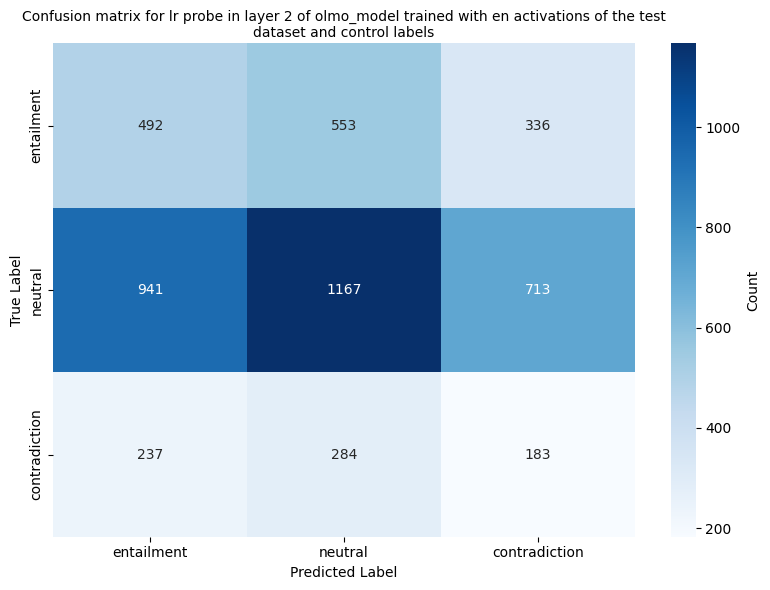

In [5]:
# for model_name in model_names:
#     for split in ["test", "train"]:
#         for language in languages:
#             for probing_task in probing_tasks:
#                 exp_result: ExperimentResult = ExperimentResult.get_from_file(
#                     1, language, probing_task, probe_type, model_name
#                 )

#                 for layer_num in range(exp_result.get_num_layers()):
#                     plot_confusion_matrix(exp_result, split, layer_num)

for probing_task in ["standard", "control"]:
    exp_result: ExperimentResult = ExperimentResult.get_from_file(1, "en", probing_task, probe_type, "olmo_model")

    for layer_num in range(exp_result.get_num_layers()):
        plot_confusion_matrix(exp_result, "test", layer_num)

# Experiment 2

ic| force_probe_creation: False, run_experiment: False


Using default settings
Plot saved to plots\experiment_1_plots.png


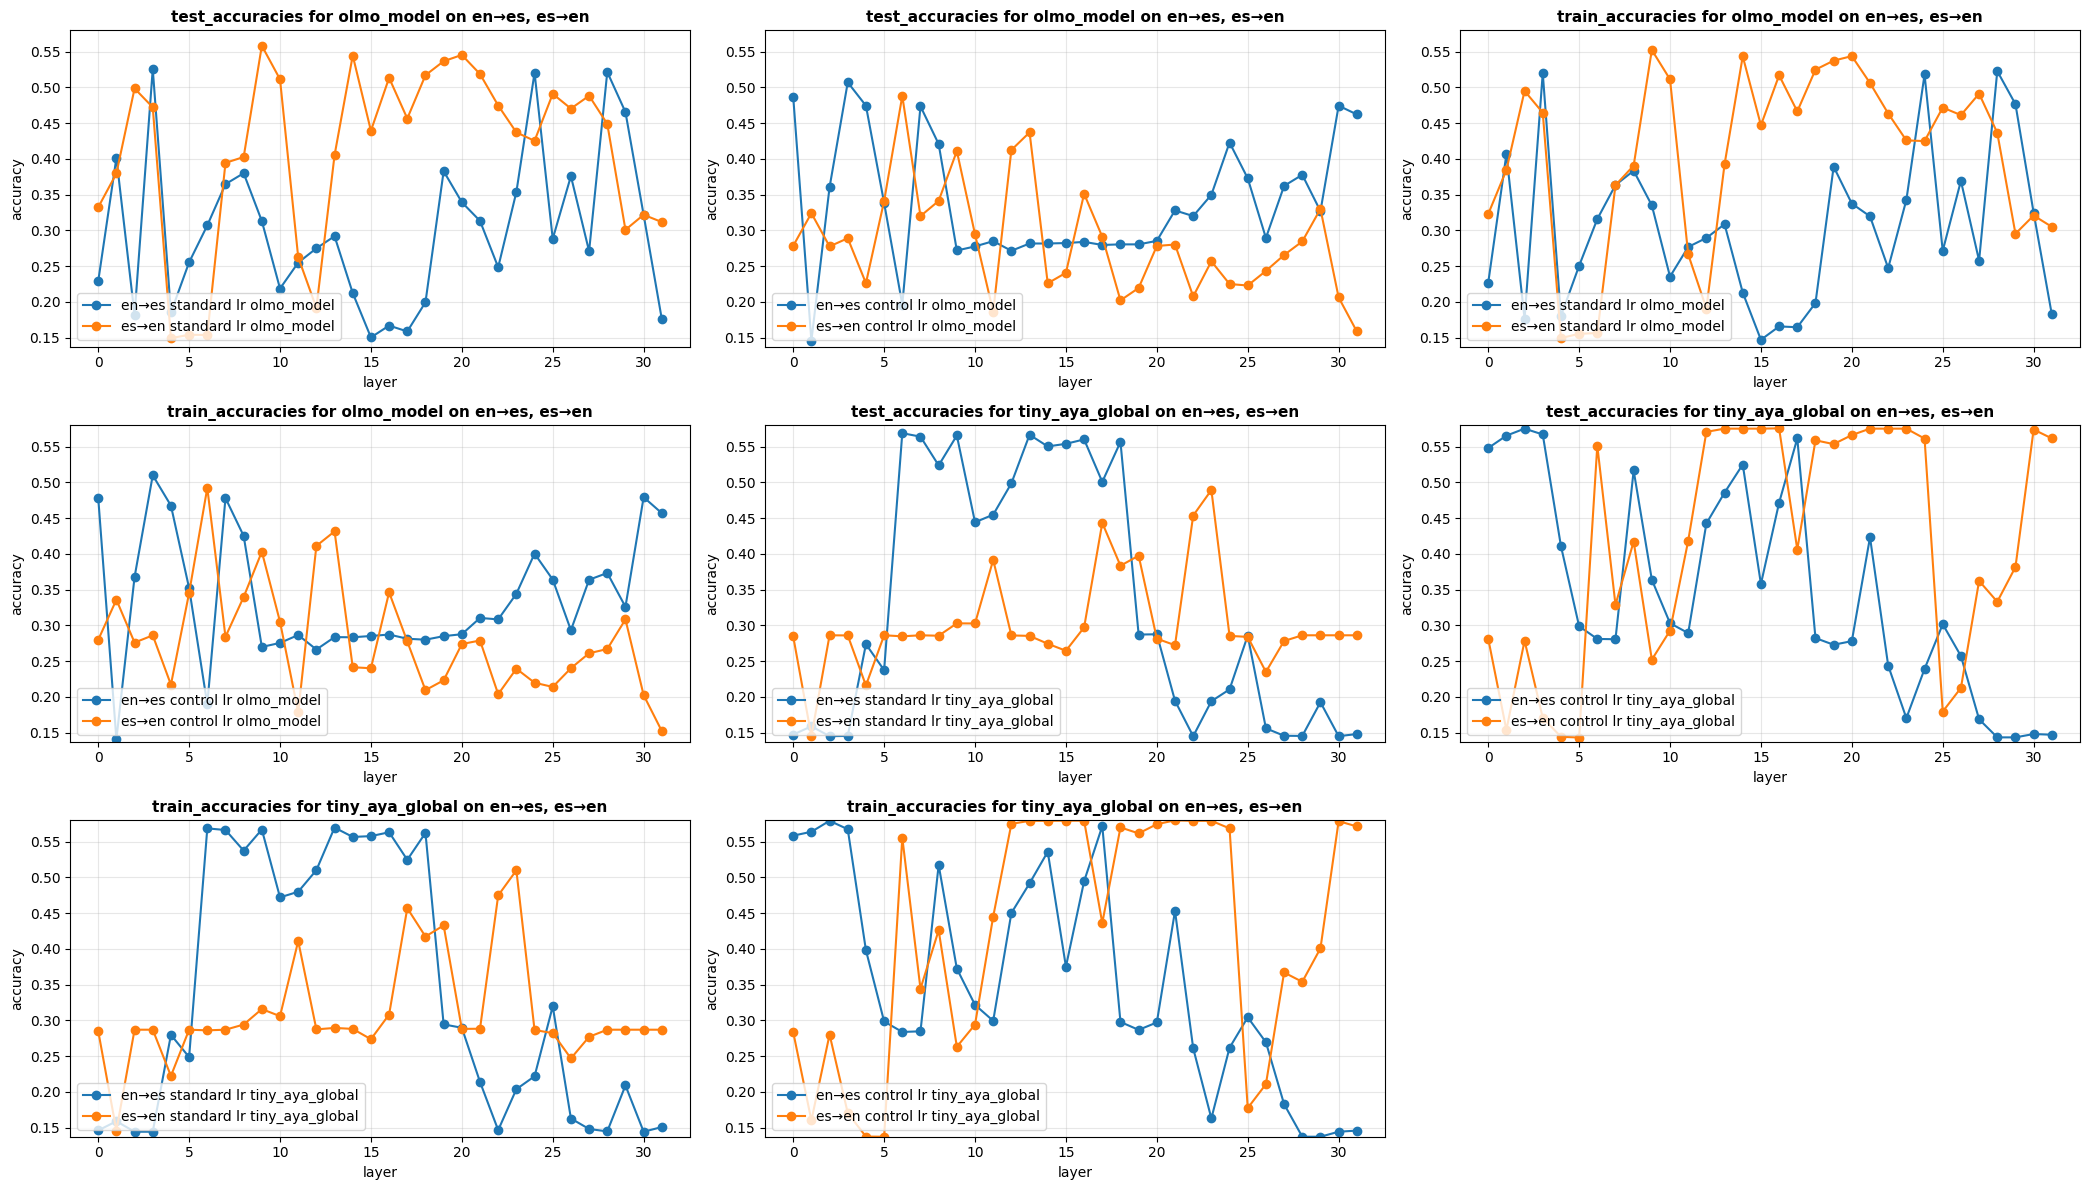

In [ ]:
from experiment_2 import run_experiment_2, get_language_merged_string

model_names: list[str] = MODEL_NAMES
language_pairs: list[tuple[str, str]] = list(permutations(LANGUAGES, 2))
probing_tasks: list[str] = SIMPLE_PROBING_TASKS
probe_type: str = "lr"

custom = False
if custom:
    model_names = ["olmo_model"]
    language_pairs = [("es", "en")]
    probing_tasks = ["standard"]
    probe_type = "lr"
    print(f"Using custom configuration")
    ic(model_names, language_pairs, probing_tasks, probe_type)
else:
    print(f"Using default settings")

force_probe_creation: bool = False
run_experiment: bool = False

ic(force_probe_creation, run_experiment)

# If run_experiment, run the experiment and save the results as files.
if run_experiment:
    run_experiment_2(language_pairs, probing_tasks, probe_type, model_names, force_probe_creation)

plots_to_make: list[list[tuple[ExperimentResult, str]]] = []
for model_name in model_names:
    for metric_type in metric_types:
        # Get all the experiments for this model across all languages and probing_tasks
        for probing_task in probing_tasks: 
            experiments_in_plot: list[tuple[ExperimentResult, str]] = []
            for (language_a, language_b) in language_pairs:
                language_merged_string: str = get_language_merged_string(language_a, language_b)
                exp_result: ExperimentResult = ExperimentResult.get_from_file(
                    2, language_merged_string, probing_task, probe_type, model_name
                )
                experiments_in_plot.append((exp_result, metric_type))

            plots_to_make.append(experiments_in_plot)
# Make some plots
plot_metrics_by_group(plots_to_make, "layer", "accuracy", show=True, save=True, filename="experiment_2_plots", scale=1)

In [4]:
test_dict = {"train": {}, "test": {}}
test_dict["test"]["accuracy"].append(0.8)

KeyError: 'accuracy'